# 1. óra — Statisztikai alapok: élő demók

Ezt a notebookot óra közben vetítjük ki, a `lesson-plan.md`-ben jelzett pontokon.
Nem önálló tananyag — a `slides.md` + `lesson-plan.md` adja a keretet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (7, 4)

## 1. Monty Hall — szimuláció

A táblás játék után: fussunk le sok ezer kört, és nézzük meg empirikusan, mennyivel
jobb váltani.

In [2]:
def monty_hall_trial(switch: bool, rng: np.random.Generator) -> bool:
    doors = [0, 0, 0]
    winning_door = rng.integers(3)
    doors[winning_door] = 1

    choice = rng.integers(3)

    # a műsorvezető egy olyan ajtót nyit ki, ami (a) nem a választott, (b) nem a nyertes
    remaining = [d for d in range(3) if d != choice and d != winning_door]
    host_opens = rng.choice(remaining)

    if switch:
        choice = [d for d in range(3) if d != choice and d != host_opens][0]

    return choice == winning_door


n_trials = 20_000
stay_wins = sum(monty_hall_trial(switch=False, rng=rng) for _ in range(n_trials))
switch_wins = sum(monty_hall_trial(switch=True, rng=rng) for _ in range(n_trials))

print(f"Marad, nyerési arány:  {stay_wins / n_trials:.1%}")
print(f"Vált, nyerési arány:   {switch_wins / n_trials:.1%}")

Marad, nyerési arány:  33.3%
Vált, nyerési arány:   66.9%


## 2. Bayes — a teszt paradoxona

Prevalencia 1%, szenzitivitás 99%, specificitás 99%. Pozitív lettél — mekkora
eséllyel vagy tényleg beteg?

In [3]:
prevalence = 0.01
sensitivity = 0.99  # P(pozitív | beteg)
specificity = 0.99  # P(negatív | egészséges)

p_disease = prevalence
p_positive_given_disease = sensitivity
p_positive_given_healthy = 1 - specificity

p_positive = (
    p_positive_given_disease * p_disease
    + p_positive_given_healthy * (1 - p_disease)
)

p_disease_given_positive = (p_positive_given_disease * p_disease) / p_positive
print(f"P(beteg | pozitív teszt) = {p_disease_given_positive:.1%}")

P(beteg | pozitív teszt) = 50.0%


## 3. Nagy számok törvénye

Fair érme dobások futó átlaga — nézzük meg, mennyire "esedékes" az írás 8 fej
után (nem az).

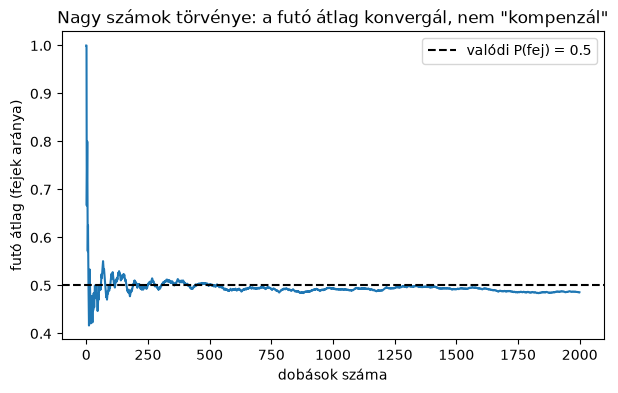

In [4]:
n_flips = 2000
flips = rng.integers(0, 2, size=n_flips)  # 1 = fej
running_mean = np.cumsum(flips) / np.arange(1, n_flips + 1)

plt.plot(running_mean)
plt.axhline(0.5, color="black", linestyle="--", label="valódi P(fej) = 0.5")
plt.xlabel("dobások száma")
plt.ylabel("futó átlag (fejek aránya)")
plt.title("Nagy számok törvénye: a futó átlag konvergál, nem \"kompenzál\"")
plt.legend()
plt.show()

## 4. Centrális határeloszlás-tétel

Erősen ferde (exponenciális) eloszlásból veszünk mintát — és nézzük, milyen alakot
vesz fel a mintaátlagok eloszlása, ahogy n nő.

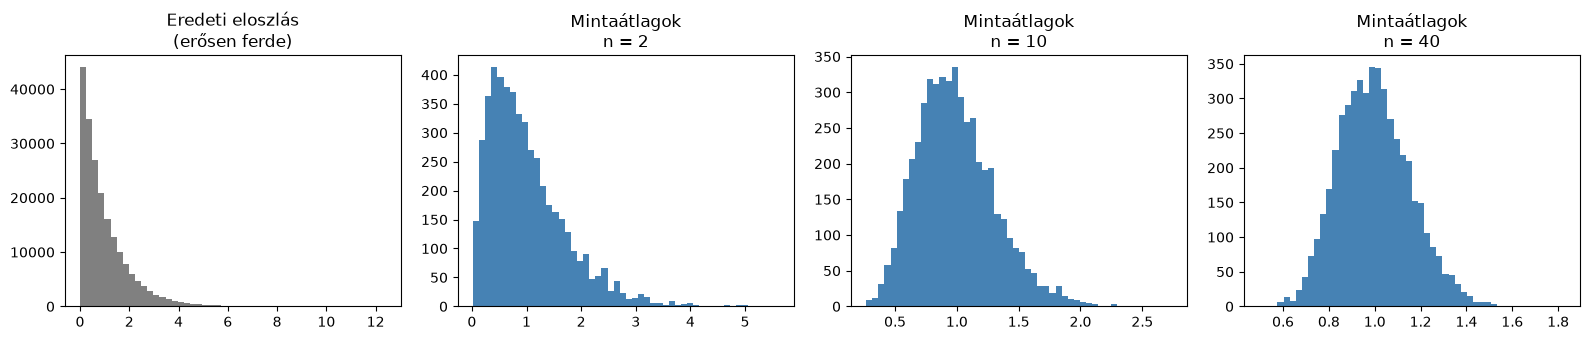

In [5]:
population = rng.exponential(scale=1.0, size=200_000)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

axes[0].hist(population, bins=50, color="grey")
axes[0].set_title("Eredeti eloszlás\n(erősen ferde)")

for ax, n in zip(axes[1:], [2, 10, 40]):
    sample_means = [rng.exponential(scale=1.0, size=n).mean() for _ in range(5000)]
    ax.hist(sample_means, bins=50, color="steelblue")
    ax.set_title(f"Mintaátlagok\nn = {n}")

plt.tight_layout()
plt.show()

## 5. Hipotézisvizsgálat — mit jelent valójában a p-érték?

Szintetikus A/B teszt: két csoport konverziós rátája között látszólagos
különbség van. Permutációs teszttel *empirikusan* mutatjuk meg, mit jelent a
p-érték — nem csak kimondjuk a definíciót.

Megfigyelt különbség (B - A): -0.2%
p-érték: 1.000


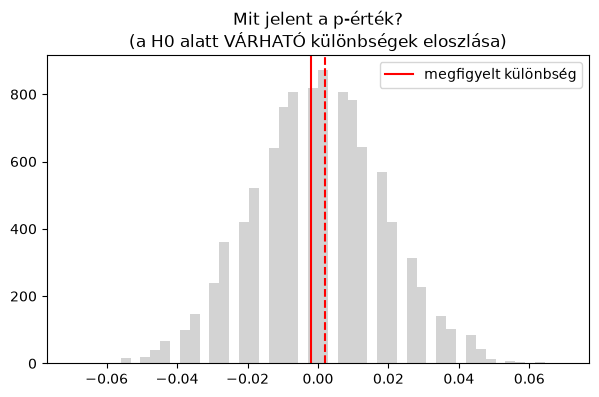

In [6]:
# szintetikus adat: A és B csoport, NINCS valódi különbség (H0 igaz)
n_per_group = 500
true_conversion_rate = 0.10

group_a = rng.binomial(1, true_conversion_rate, size=n_per_group)
group_b = rng.binomial(1, true_conversion_rate, size=n_per_group)

observed_diff = group_b.mean() - group_a.mean()
print(f"Megfigyelt különbség (B - A): {observed_diff:+.1%}")

# permutációs teszt: ha H0 igaz (nincs különbség), a csoport-címke felcserélhető
pooled = np.concatenate([group_a, group_b])
n_permutations = 10_000
perm_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    shuffled = rng.permutation(pooled)
    perm_diffs[i] = shuffled[n_per_group:].mean() - shuffled[:n_per_group].mean()

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f"p-érték: {p_value:.3f}")

plt.hist(perm_diffs, bins=50, color="lightgrey")
plt.axvline(observed_diff, color="red", label="megfigyelt különbség")
plt.axvline(-observed_diff, color="red", linestyle="--")
plt.title("Mit jelent a p-érték?\n(a H0 alatt VÁRHATÓ különbségek eloszlása)")
plt.legend()
plt.show()

## 6. Korreláció vs. kauzalitás — konfounder demó

Fagylaltfogyasztás és vízbefulladások: együtt mozognak, de nincs közöttük
közvetlen ok-okozat — a közös ok a hőmérséklet.

In [7]:
n_days = 365
temperature = rng.normal(20, 8, size=n_days)

ice_cream_sales = 50 + 3 * temperature + rng.normal(0, 10, size=n_days)
drownings = 2 + 0.15 * temperature + rng.normal(0, 1.5, size=n_days)
drownings = np.clip(drownings, 0, None)

df = pd.DataFrame({
    "temperature": temperature,
    "ice_cream_sales": ice_cream_sales,
    "drownings": drownings,
})

print("Nyers korreláció (fagyi vs. fulladás):",
      round(df["ice_cream_sales"].corr(df["drownings"]), 2))

# kontrolláljunk a hőmérsékletre: nézzük a reziduumok korrelációját
resid_ice_cream = df["ice_cream_sales"] - LinearRegression().fit(
    df[["temperature"]], df["ice_cream_sales"]
).predict(df[["temperature"]])
resid_drownings = df["drownings"] - LinearRegression().fit(
    df[["temperature"]], df["drownings"]
).predict(df[["temperature"]])

print("Korreláció hőmérsékletre kontrollálva:",
      round(np.corrcoef(resid_ice_cream, resid_drownings)[0, 1], 2))

Nyers korreláció (fagyi vs. fulladás): 0.59
Korreláció hőmérsékletre kontrollálva: 0.08


## 7. Simpson-paradoxon — UC Berkeley-stílusú toy példa

Szintetikus felvételi adat két tanszékkel. Nézzük meg az összesített és a
tanszékenkénti arányokat.

In [8]:
admissions = pd.DataFrame({
    "dept": ["A"] * 200 + ["A"] * 800 + ["B"] * 800 + ["B"] * 200,
    "gender": ["férfi"] * 200 + ["nő"] * 800 + ["férfi"] * 800 + ["nő"] * 200,
    # A tanszék (kevésbé versenyzett): magas felvételi arány
    # B tanszék (versenyzett): alacsony felvételi arány
    "admitted": (
        list(rng.binomial(1, 0.60, 200))   # férfi, A tanszék
        + list(rng.binomial(1, 0.65, 800))  # nő, A tanszék
        + list(rng.binomial(1, 0.30, 800))  # férfi, B tanszék
        + list(rng.binomial(1, 0.35, 200))  # nő, B tanszék
    ),
})

print("Összesített felvételi arány nemenként:")
print(admissions.groupby("gender")["admitted"].mean().round(2))

print("\nTanszékenkénti felvételi arány:")
print(admissions.groupby(["dept", "gender"])["admitted"].mean().round(2))

Összesített felvételi arány nemenként:
gender
férfi    0.38
nő       0.57
Name: admitted, dtype: float64

Tanszékenkénti felvételi arány:
dept  gender
A     férfi     0.64
      nő        0.62
B     férfi     0.31
      nő        0.34
Name: admitted, dtype: float64


## 8. Dimenzió-átok

Véletlenszerű pontok egységkockában, növekvő dimenziószámmal — nézzük, hogyan
tűnik el a különbség a legközelebbi és legtávolabbi szomszéd távolsága között.

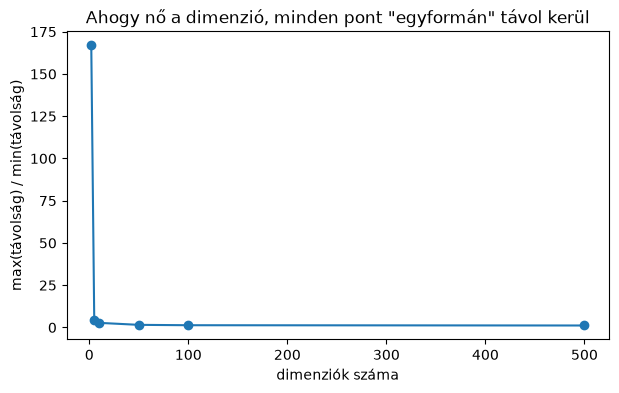

In [9]:
n_points = 1000
dimensions = [2, 5, 10, 50, 100, 500]
ratios = []

for d in dimensions:
    points = rng.uniform(0, 1, size=(n_points, d))
    origin = np.zeros(d)
    distances = np.linalg.norm(points - origin, axis=1)
    ratios.append(distances.max() / distances.min())

plt.plot(dimensions, ratios, marker="o")
plt.xlabel("dimenziók száma")
plt.ylabel("max(távolság) / min(távolság)")
plt.title("Ahogy nő a dimenzió, minden pont \"egyformán\" távol kerül")
plt.show()

## 9. Lineáris regresszió

Egyszerű szintetikus adat, legkisebb négyzetek illesztés.

Illesztett egyenes: y = 2.61 * x + 3.87


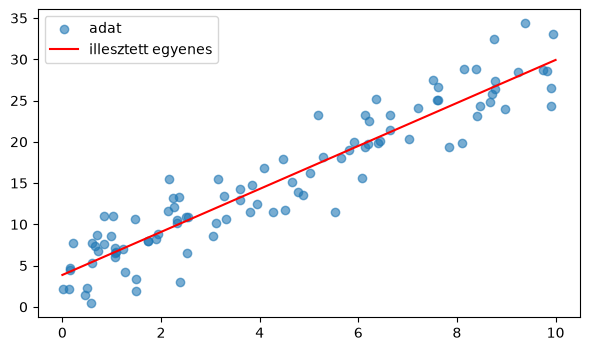

In [10]:
x = rng.uniform(0, 10, size=100)
y = 2.5 * x + 5 + rng.normal(0, 3, size=100)

model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"Illesztett egyenes: y = {model.coef_[0]:.2f} * x + {model.intercept_:.2f}")

plt.scatter(x, y, alpha=0.6, label="adat")
x_line = np.linspace(0, 10, 100)
plt.plot(x_line, model.predict(x_line.reshape(-1, 1)), color="red", label="illesztett egyenes")
plt.legend()
plt.show()

## 10. Lineáris valószínűségi modell → logisztikus regresszió

Bináris kimenet (pl. lemorzsolódás) — előbb megpróbáljuk lineáris regresszióval
(LPM), aztán megnézzük, hol romlik el, és áttérünk logisztikus regresszióra.

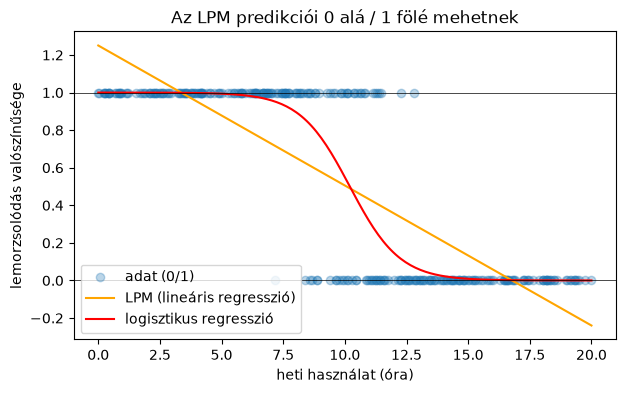

LPM predikció min/max: -0.24 / 1.25
Logisztikus predikció min/max: 0.00 / 1.00


In [11]:
usage_hours = rng.uniform(0, 20, size=300)
# minél kevesebbet használja, annál nagyobb eséllyel morzsolódik le
churn_prob_true = 1 / (1 + np.exp(usage_hours - 10))
churned = rng.binomial(1, churn_prob_true)

lpm = LinearRegression().fit(usage_hours.reshape(-1, 1), churned)
logit = LogisticRegression().fit(usage_hours.reshape(-1, 1), churned)

x_line = np.linspace(0, 20, 200).reshape(-1, 1)
lpm_pred = lpm.predict(x_line)
logit_pred = logit.predict_proba(x_line)[:, 1]

plt.scatter(usage_hours, churned, alpha=0.3, label="adat (0/1)")
plt.plot(x_line, lpm_pred, color="orange", label="LPM (lineáris regresszió)")
plt.plot(x_line, logit_pred, color="red", label="logisztikus regresszió")
plt.axhline(0, color="black", linewidth=0.5)
plt.axhline(1, color="black", linewidth=0.5)
plt.xlabel("heti használat (óra)")
plt.ylabel("lemorzsolódás valószínűsége")
plt.legend()
plt.title("Az LPM predikciói 0 alá / 1 fölé mehetnek")
plt.show()

print(f"LPM predikció min/max: {lpm_pred.min():.2f} / {lpm_pred.max():.2f}")
print(f"Logisztikus predikció min/max: {logit_pred.min():.2f} / {logit_pred.max():.2f}")